# 1. Ajustando a localização do Código

## Isso força o locale de datas para inglês, evitando erro ao interpretar meses como “Aug”, “Sep” etc.

In [29]:
import locale
locale.setlocale(locale.LC_TIME, "English_United States") 

'English_United States.1252'

In [30]:
import soccerdata as sd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregando o Dataset

In [31]:
understat = sd.Understat(
    leagues="ENG-Premier League",
    seasons=2022
)



[2/2/2026 10:30:43 PM] INFO     Saving cached data to C:\Users\User\soccerdata\data\Understat        ]8;id=1792;file://c:\Users\User\fut_data\venv\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=14273;file://c:\Users\User\fut_data\venv\Lib\site-packages\soccerdata\_common.py#249\249]8;;\

In [32]:
team_stats = understat.read_team_match_stats()
team_stats = team_stats.reset_index()
team_stats["date"] = pd.to_datetime(team_stats["date"], errors="coerce")
team_stats = team_stats.sort_values("date")

team_stats.head()


,league,season,game,league_id,season_id,game_id,date,home_team_id,away_team_id,home_team,...,away_ppda,away_deep_completions,home_points,home_expected_points,home_goals,home_xg,home_np_xg,home_np_xg_difference,home_ppda,home_deep_completions
0,ENG-Premier League,2223,2022-08-05 Crystal Palace-Arsenal,1,2022,18202,2022-08-05 19:00:00,78,83,Crystal Palace,...,12.678571,13,0,1.1504,0,1.20637,1.20637,-0.22964,10.25,8
3,ENG-Premier League,2223,2022-08-06 Fulham-Liverpool,1,2022,18203,2022-08-06 11:30:00,228,87,Fulham,...,6.333333,11,1,0.5808,2,1.26822,0.507047,-1.834063,18.473684,4
1,ENG-Premier League,2223,2022-08-06 Bournemouth-Aston Villa,1,2022,18204,2022-08-06 14:00:00,73,71,Bournemouth,...,6.608696,11,3,1.4036,2,0.588341,0.588341,0.099446,11.68,3
4,ENG-Premier League,2223,2022-08-06 Leeds-Wolverhampton Wanderers,1,2022,18205,2022-08-06 14:00:00,245,229,Leeds,...,10.647059,9,3,1.156,2,0.88917,0.88917,-0.21202,9.285714,5
5,ENG-Premier League,2223,2022-08-06 Newcastle United-Nottingham Forest,1,2022,18206,2022-08-06 14:00:00,86,249,Newcastle United,...,13.333333,2,3,2.5764,2,1.8591,1.8591,1.623275,6.08,24


# 2. Separando Visitante e Mandante via Dataframes

In [33]:
home = team_stats[[
    "season", "league", "game_id", "date",
    "home_team", "away_team",
    "home_goals", "home_xg", "home_np_xg",
    "home_points", "home_expected_points",
    "home_ppda", "home_deep_completions"
]].copy()

home = home.rename(columns={
    "home_team": "team",
    "away_team": "opponent",
    "home_goals": "goals",
    "home_xg": "xg",
    "home_np_xg": "np_xg",
    "home_points": "points",
    "home_expected_points": "expected_points",
    "home_ppda": "ppda",
    "home_deep_completions": "deep_completions",
})

home["home_away"] = "home"


In [34]:
away = team_stats[[
    "season", "league", "game_id", "date",
    "away_team", "home_team",
    "away_goals", "away_xg", "away_np_xg",
    "away_points", "away_expected_points",
    "away_ppda", "away_deep_completions"
]].copy()

away = away.rename(columns={
    "away_team": "team",
    "home_team": "opponent",
    "away_goals": "goals",
    "away_xg": "xg",
    "away_np_xg": "np_xg",
    "away_points": "points",
    "away_expected_points": "expected_points",
    "away_ppda": "ppda",
    "away_deep_completions": "deep_completions",
})

away["home_away"] = "away"

In [35]:
team_match = pd.concat([home, away], ignore_index=True)

team_match["date"] = pd.to_datetime(team_match["date"], errors="coerce")
team_match = team_match.sort_values(["team", "date", "game_id"]).reset_index(drop=True)

team_match.head()


,season,league,game_id,date,team,opponent,goals,xg,np_xg,points,expected_points,ppda,deep_completions,home_away
0,2223,ENG-Premier League,18202,2022-08-05 19:00:00,Arsenal,Crystal Palace,2,1.43601,1.43601,3,1.5584,12.678571,13,away
1,2223,ENG-Premier League,18217,2022-08-13 14:00:00,Arsenal,Leicester,4,3.0107,3.0107,3,2.7487,10.333333,10,home
2,2223,ENG-Premier League,18227,2022-08-20 16:30:00,Arsenal,Bournemouth,3,1.71081,1.71081,3,2.6009,8.72,8,away
3,2223,ENG-Premier League,18238,2022-08-27 16:30:00,Arsenal,Fulham,2,2.47427,2.47427,3,2.4378,5.421053,17,home
4,2223,ENG-Premier League,18247,2022-08-31 18:30:00,Arsenal,Aston Villa,2,2.79971,2.79971,3,2.8527,9.882353,18,home


In [36]:
team_match["team"].unique()

<StringArray>
[                'Arsenal',             'Aston Villa',
             'Bournemouth',               'Brentford',
                'Brighton',                 'Chelsea',
          'Crystal Palace',                 'Everton',
                  'Fulham',                   'Leeds',
               'Leicester',               'Liverpool',
         'Manchester City',       'Manchester United',
        'Newcastle United',       'Nottingham Forest',
             'Southampton',               'Tottenham',
                'West Ham', 'Wolverhampton Wanderers']
Length: 20, dtype: string

# 3. Criando as estatísticas de Diferença de xG e Diferença de xG sem pênaltis

In [37]:
team_match["xg_diff"] = team_match["goals"] - team_match["xg"]
team_match["np_xg_diff"] = team_match["goals"] - team_match["np_xg"]


In [38]:
team_season = (
    team_match
    .groupby(["season", "league", "team"], as_index=False)
    .agg(
        games=("game_id", "count"),
        goals=("goals", "sum"),
        xg=("xg", "sum"),
        np_xg=("np_xg", "sum"),
        xg_diff=("xg_diff", "sum"),
        np_xg_diff=("np_xg_diff", "sum"),
        points=("points", "sum"),
        expected_points=("expected_points", "sum"),
        ppda=("ppda", "mean"),
        deep_completions=("deep_completions", "sum"),
    )
)

team_season["xg_diff_per_game"] = team_season["xg_diff"] / team_season["games"]
team_season["np_xg_diff_per_game"] = team_season["np_xg_diff"] / team_season["games"]


# 3.1 Eficiência ofensiva: Gols vs xG

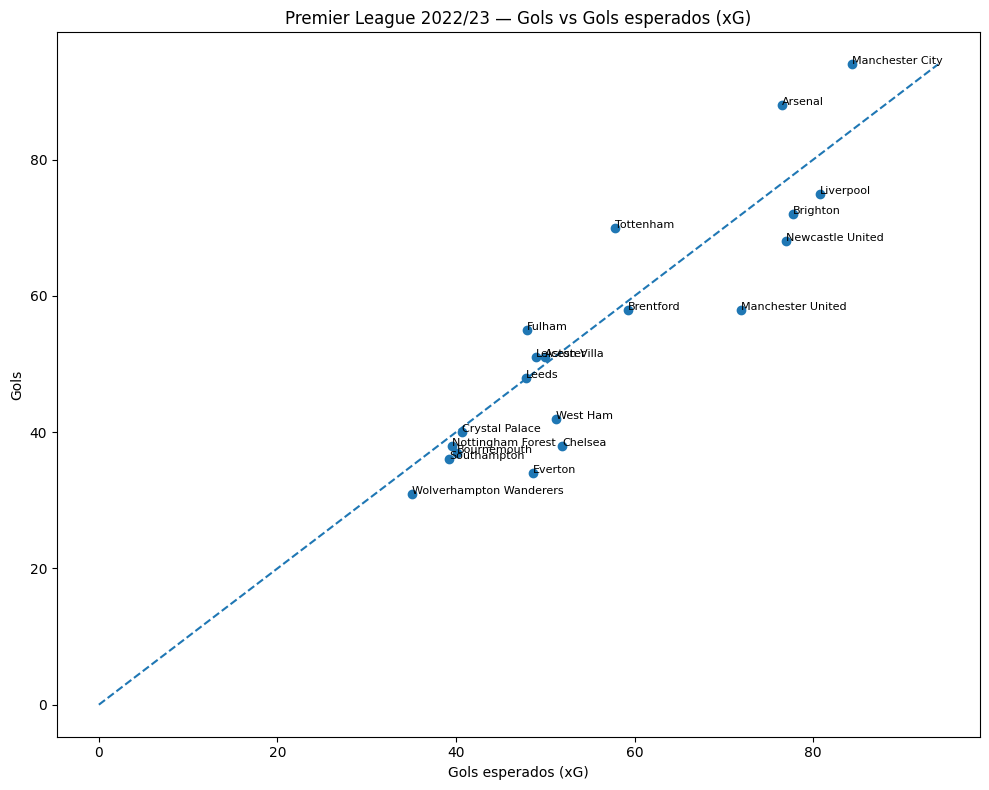

In [67]:
plt.figure(figsize=(10, 8))

plt.scatter(team_season["xg"], team_season["goals"])

# Linha de referência y = x
max_val = max(team_season["xg"].max(), team_season["goals"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--")

# Nome dos times
for _, row in team_season.iterrows():
    plt.text(row["xg"], row["goals"], row["team"], fontsize=8)

plt.title("Premier League 2022/23 — Gols vs Gols esperados (xG)")
plt.xlabel("Gols esperados (xG)")
plt.ylabel("Gols")
plt.tight_layout()
plt.show()
plt.close()


# 4. Rolling 

In [39]:
team_match = team_match.sort_values(
    ["team", "date", "game_id"]
).reset_index(drop=True)

In [40]:
# Rolling 5 jogos
team_match["np_xg_roll_5"] = (
    team_match.groupby("team")["np_xg"]
    .rolling(window=5, min_periods=1).mean()
    .reset_index(level=0, drop=True)
)

team_match["goals_roll_5"] = (
    team_match
    .groupby("team")["goals"]
    .rolling(window=5, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

# Rolling 10 jogos
team_match["xg_roll_10"] = (
    team_match
    .groupby("team")["xg"]
    .rolling(window=10, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

In [41]:
team_match["np_xg_diff_roll_5"] = team_match["goals_roll_5"] - team_match["np_xg_roll_5"]

In [42]:
assert team_stats["game_id"].nunique() == 380, "Quantidade de jogos inesperada"
assert len(team_match) == 760, "O long format deveria ter 760 linhas"
assert team_match["date"].notna().mean() > 0.99, "Muitas datas nulas"


In [43]:
season_avg = (
    team_match
    .groupby("team", as_index=False)
    .agg(
        xg_season_avg=("xg", "mean"),
        goals_season_avg=("goals", "mean")
    )
)

In [44]:
team_match = team_match.merge(
    season_avg,
    on="team",
    how="left"
)

In [45]:
team_name = "Arsenal"

df_team = team_match[team_match["team"] == team_name]


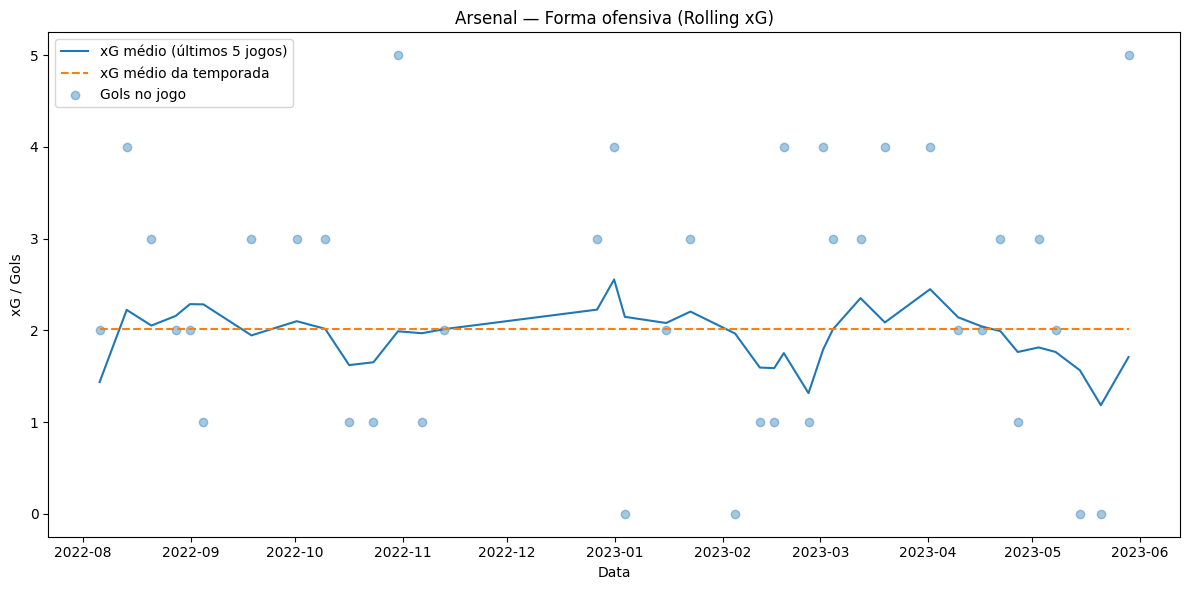

In [46]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_team["date"],
    df_team["np_xg_roll_5"],
    label="xG médio (últimos 5 jogos)"
)

plt.plot(
    df_team["date"],
    df_team["xg_season_avg"],
    linestyle="--",
    label="xG médio da temporada"
)

plt.scatter(
    df_team["date"],
    df_team["goals"],
    alpha=0.4,
    label="Gols no jogo"
)

plt.title(f"{team_name} — Forma ofensiva (Rolling xG)")
plt.xlabel("Data")
plt.ylabel("xG / Gols")
plt.legend()
plt.tight_layout()
plt.show()



# 5. Pontos reais vs pontos esperados

In [47]:
team_season["points_diff"] = team_season["points"] - team_season["expected_points"]
team_season["points_diff_per_game"] = team_season["points_diff"] / team_season["games"]


# 5.1 Ranking de Over/underperformance em pontos

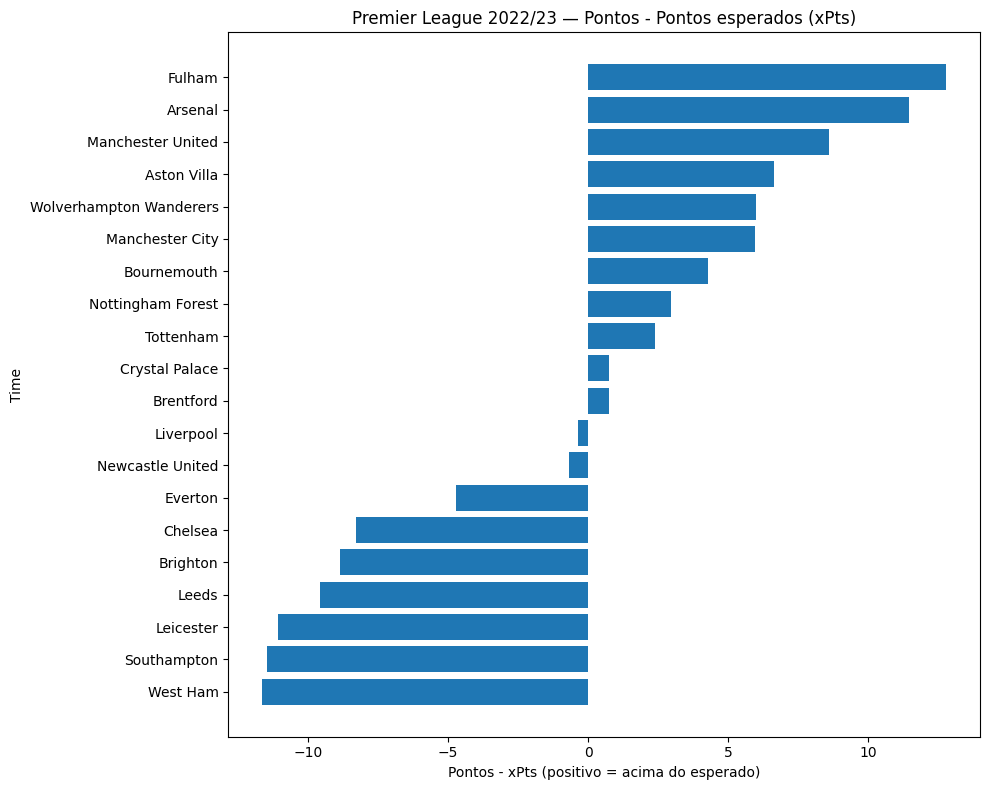

In [68]:
df_rank = team_season.sort_values("points_diff")

plt.figure(figsize=(10, 8))
plt.barh(df_rank["team"], df_rank["points_diff"])
plt.title("Premier League 2022/23 — Pontos - Pontos esperados (xPts)")
plt.xlabel("Pontos - xPts (positivo = acima do esperado)")
plt.ylabel("Time")
plt.tight_layout()
plt.show()


# 5.2 Scatter: Pontos vs xPts

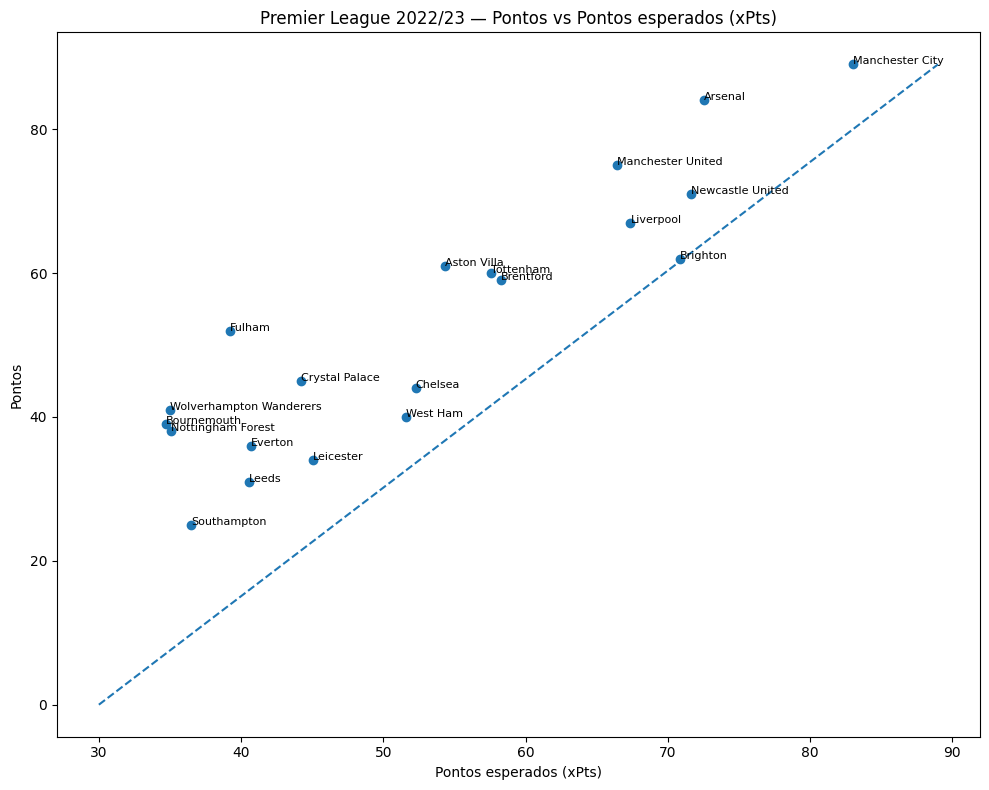

In [69]:
plt.figure(figsize=(10, 8))

plt.scatter(team_season["expected_points"], team_season["points"])

max_val = max(team_season["expected_points"].max(), team_season["points"].max())
plt.plot([30, max_val], [0, max_val], linestyle="--")

for _, row in team_season.iterrows():
    plt.text(row["expected_points"], row["points"], row["team"], fontsize=8)

plt.title("Premier League 2022/23 — Pontos vs Pontos esperados (xPts)")
plt.xlabel("Pontos esperados (xPts)")
plt.ylabel("Pontos")
plt.tight_layout()
plt.savefig(
    r"C:\Users\User\fut_data\images\pontos_vs_xpts.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()
plt.close()

# 6. Forma de pontos e xPts

In [50]:
team_match = team_match.sort_values(["team", "date", "game_id"]).reset_index(drop=True)

team_match["points_roll_5"] = (
    team_match.groupby("team")["points"]
    .rolling(window=5, min_periods=1).mean()
    .reset_index(level=0, drop=True)
)

team_match["xpts_roll_5"] = (
    team_match.groupby("team")["expected_points"]
    .rolling(window=5, min_periods=1).mean()
    .reset_index(level=0, drop=True)
)

team_match["points_diff_roll_5"] = team_match["points_roll_5"] - team_match["xpts_roll_5"]


# 6.1 Média da temporada (Pontos)

In [51]:
season_avg_pts = (
    team_match.groupby("team", as_index=False)
    .agg(
        points_season_avg=("points", "mean"),
        xpts_season_avg=("expected_points", "mean")
    )
)

team_match = team_match.merge(season_avg_pts, on="team", how="left")


# 6.2 Gráfico de forma: Pontos vs xPts 

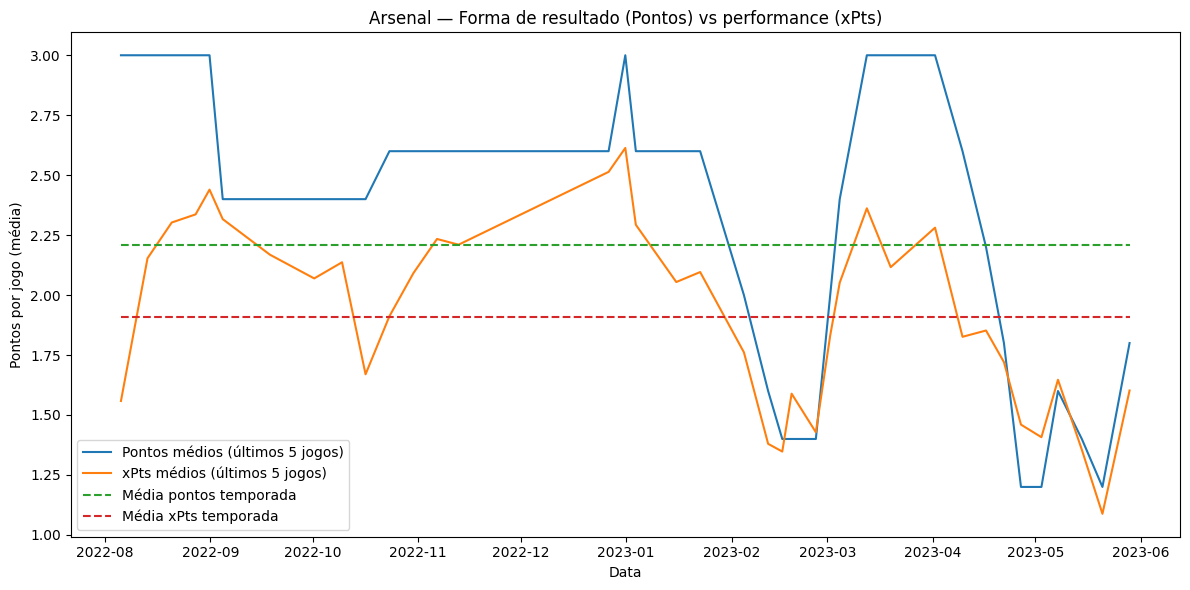

In [52]:
team_name = "Arsenal"
df_team = team_match[team_match["team"] == team_name]

plt.figure(figsize=(12, 6))

plt.plot(df_team["date"], df_team["points_roll_5"], label="Pontos médios (últimos 5 jogos)")
plt.plot(df_team["date"], df_team["xpts_roll_5"], label="xPts médios (últimos 5 jogos)")

plt.plot(df_team["date"], df_team["points_season_avg"], linestyle="--", label="Média pontos temporada")
plt.plot(df_team["date"], df_team["xpts_season_avg"], linestyle="--", label="Média xPts temporada")

plt.title(f"{team_name} — Forma de resultado (Pontos) vs performance (xPts)")
plt.xlabel("Data")
plt.ylabel("Pontos por jogo (média)")
plt.legend()
plt.tight_layout()
plt.show()


# 7. Unindo criação de gols (xG), Performance (xPts) e resultados reais em pontos

In [53]:
team_match["np_xg_roll_5"] = (
    team_match
    .groupby("team")["np_xg"]
    .rolling(window=5, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

team_match["np_xg_roll_10"] = (
    team_match
    .groupby("team")["np_xg"]
    .rolling(window=10, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)


# 7.1 Diferenças de curto prazo

In [54]:
team_match["np_xg_diff_roll_5"] = (
    team_match["goals_roll_5"] - team_match["np_xg_roll_5"]
)

team_match["points_diff_roll_5"] = (
    team_match["points_roll_5"] - team_match["xpts_roll_5"]
)


# 7.2 Gráfico “completo” de forma (1 time)

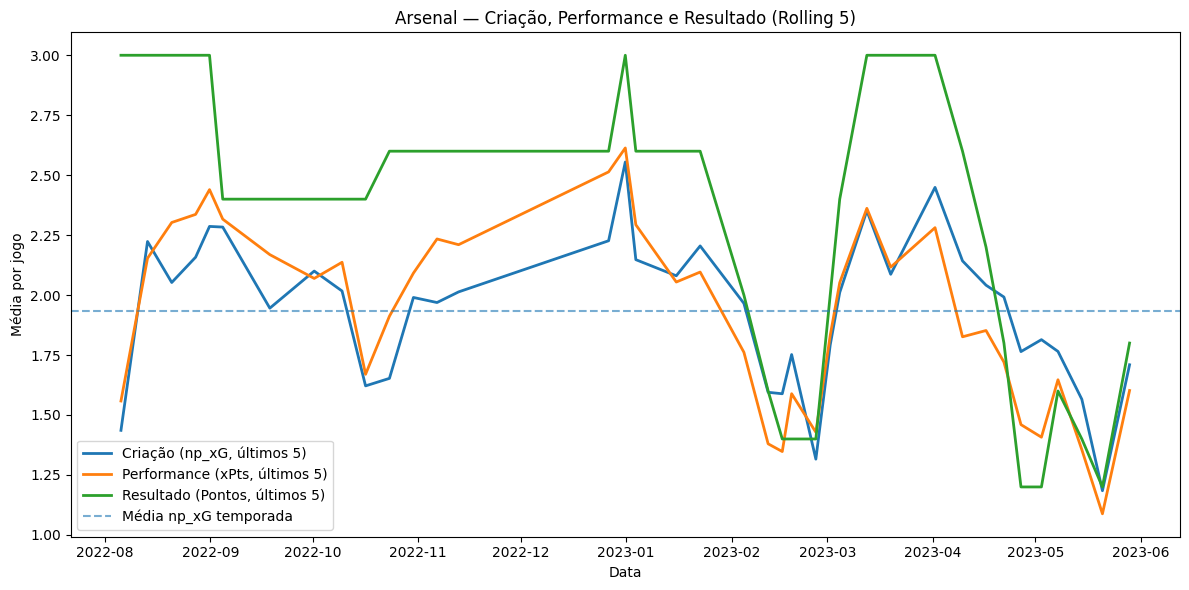

In [ ]:
team_name = "Arsenal"
df_team = team_match[team_match["team"] == team_name]

plt.figure(figsize=(12, 6))

plt.plot(df_team["date"], df_team["np_xg_roll_5"],
         label="Criação (np_xG, últimos 5)", linewidth=2)

plt.plot(df_team["date"], df_team["xpts_roll_5"],
         label="Performance (xPts, últimos 5)", linewidth=2)

plt.plot(df_team["date"], df_team["points_roll_5"],
         label="Resultado (Pontos, últimos 5)", linewidth=2)

plt.axhline(df_team["np_xg"].mean(), linestyle="--",
            label="Média np_xG temporada", alpha=0.6)

plt.title(f"{team_name} — Criação, Performance e Resultado (Rolling 5)")
plt.xlabel("Data")
plt.ylabel("Média por jogo")
plt.legend()
plt.tight_layout()
plt.show()


# 7.3 Como ler esse gráfico

Cenários típicos:
1) np_xG ↑, xPts ↑, pontos ↑
→ domínio real e sustentável

2) np_xG ↑, xPts ↑, pontos ↓
→ time joga bem, mas resultados não vêm (má eficiência / azar)

3) np_xG ↓, xPts ↓, pontos ↑
→ resultados inflados, possível regressão

4) np_xG estável, pontos oscilam
→ variância natural do futebol


# 8. Análise Casa vs Fora

In [56]:
home_away_season = (
    team_match
    .groupby(["team", "home_away"], as_index=False)
    .agg(
        games=("game_id", "count"),
        goals=("goals", "mean"),
        np_xg=("np_xg", "mean"),
        xg=("xg", "mean"),
        points=("points", "mean"),
        expected_points=("expected_points", "mean"),
        ppda=("ppda", "mean"),
        deep_completions=("deep_completions", "mean"),
    )
)

home_away_season


,team,home_away,games,goals,np_xg,xg,points,expected_points,ppda,deep_completions
0,Arsenal,away,19,1.842105,1.621032,1.661093,2.052632,1.676737,9.8582,9.105263
1,Arsenal,home,19,2.789474,2.245685,2.36587,2.368421,2.140832,9.221493,14.684211
2,Aston Villa,away,19,0.947368,0.923403,1.043587,1.210526,1.163263,13.409554,5.894737
3,Aston Villa,home,19,1.736842,1.547685,1.587747,2.0,1.698147,13.384674,7.684211
4,Bournemouth,away,19,0.894737,0.87418,0.87418,0.894737,0.753989,17.560662,4.210526
5,Bournemouth,home,19,1.052632,1.235502,1.235502,1.157895,1.074126,18.053528,6.315789
6,Brentford,away,19,1.210526,1.224398,1.304521,1.157895,1.270353,13.410455,5.578947
7,Brentford,home,19,1.842105,1.572323,1.812692,1.947368,1.796216,11.345273,6.578947
8,Brighton,away,19,1.842105,1.754364,1.834488,1.473684,1.680742,9.871638,8.157895
9,Brighton,home,19,1.947368,2.095973,2.256219,1.789474,2.048595,9.439565,10.894737


# 8.1 Diferença casa - fora por time

In [57]:
home = home_away_season[home_away_season["home_away"] == "home"]
away = home_away_season[home_away_season["home_away"] == "away"]

home_vs_away = home.merge(
    away,
    on="team",
    suffixes=("_home", "_away")
)

home_vs_away["points_diff"] = (
    home_vs_away["points_home"] - home_vs_away["points_away"]
)

home_vs_away["np_xg_diff"] = (
    home_vs_away["np_xg_home"] - home_vs_away["np_xg_away"]
)

home_vs_away.sort_values("points_diff", ascending=False).head()


,team,home_away_home,games_home,goals_home,np_xg_home,xg_home,points_home,expected_points_home,ppda_home,deep_completions_home,...,games_away,goals_away,np_xg_away,xg_away,points_away,expected_points_away,ppda_away,deep_completions_away,points_diff,np_xg_diff
15,Nottingham Forest,home,19,1.421053,1.100993,1.261238,1.578947,1.097363,17.546697,5.157895,...,19,0.578947,0.741506,0.821628,0.421053,0.747168,19.119249,3.105263,1.157895,0.359487
11,Liverpool,home,19,2.421053,2.331722,2.451907,2.315789,2.119347,10.342236,11.421053,...,19,1.526316,1.75919,1.799251,1.210526,1.426405,9.010135,10.631579,1.105263,0.572532
13,Manchester United,home,19,1.894737,2.250018,2.330141,2.526316,2.161716,12.0887,11.421053,...,19,1.157895,1.41407,1.454131,1.421053,1.332995,11.952029,9.157895,1.105263,0.835949
19,Wolverhampton Wanderers,home,19,1.0,0.995324,1.115508,1.578947,1.106226,14.122812,4.842105,...,19,0.631579,0.733271,0.733271,0.578947,0.736305,13.341535,5.263158,1.0,0.262052
18,West Ham,home,19,1.368421,1.374963,1.535209,1.473684,1.526963,18.430919,5.105263,...,19,0.842105,0.999846,1.160093,0.631579,1.189732,16.12908,4.0,0.842105,0.375116


# 8.2 Gráfico de impacto do mando de campo

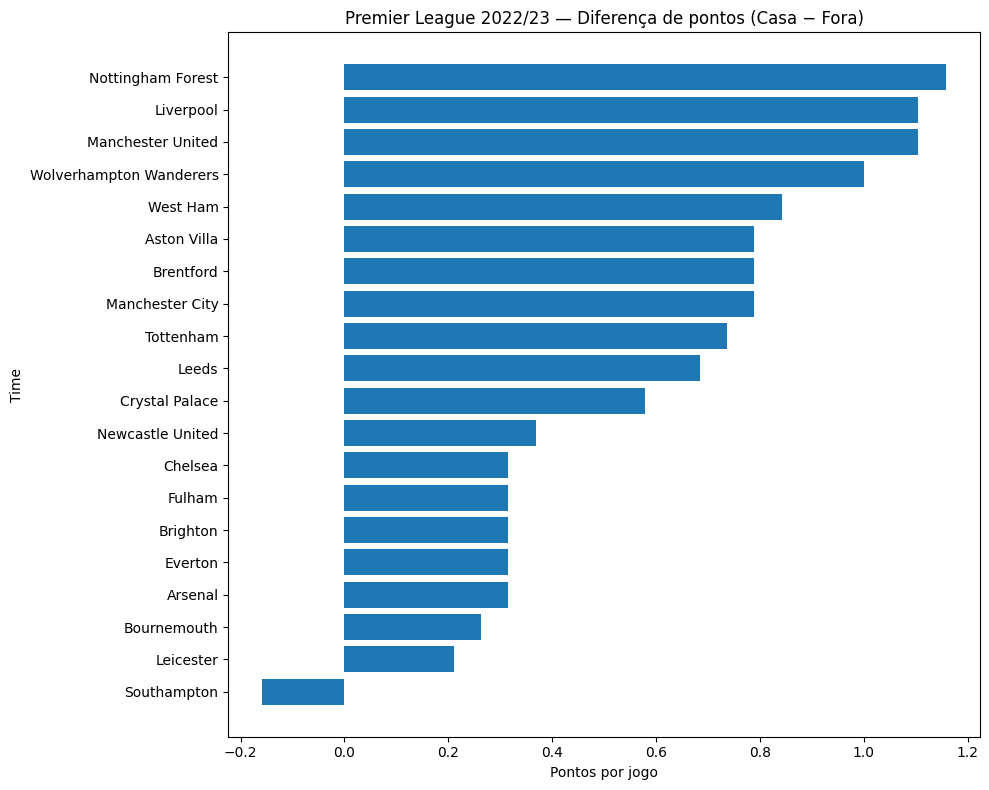

In [71]:
plt.figure(figsize=(10, 8))
plt.barh(
    home_vs_away.sort_values("points_diff")["team"],
    home_vs_away.sort_values("points_diff")["points_diff"]
)

plt.title("Premier League 2022/23 — Diferença de pontos (Casa − Fora)")
plt.xlabel("Pontos por jogo")
plt.ylabel("Time")
plt.tight_layout()
plt.savefig(
    r"C:\Users\User\fut_data\images\Casa_vs_fora.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()



Como interpretar esse gráfico:

positivo → time rende melhor em casa

próximo de zero → desempenho parecido casa vs fora

negativo → time foi melhor fora de casa do que em casa

Na temporada 2022/23 o Southampton teve péssimo aproveitamento como mandante e perdeu muitos jogos no St Mary’s, terminando rebaixado na última colocação. Ou seja, jogar em casa não foi uma vantagem para o time. Isso costuma fazer sentido já que times mais fracos tendem a jogar mais ofensivamente em casa, ao contrário de quando jogam fora onde tentam jogar mais reativos e errando menos.